## **Decision** **Tree**

# At first, we will import all the necessary packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)

Now, lets get our dataset from github raw URL then view its head.

In [ ]:
URL = "https://raw.githubusercontent.com/mdraihan27/220105_decision_tree/refs/heads/main/dataset/data.csv"
df = pd.read_csv(URL)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Lets explore our dataset and understand it.

Our first target would be to get the basic statistical idea about our dataset and find out missing values.

In [ ]:
print("=" * 60)
print("SHAPE & DTYPES")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe().T.round(3)

SHAPE & DTYPES
Rows: 569, Columns: 33

Data Types:
float64    31
int64       1
object      1
Name: count, dtype: int64

MISSING VALUES
             Missing Count  Missing %
Unnamed: 32            569      100.0

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000,869218.000,906024.000,8813129.000,9.113205e+08
radius_mean,569.0,1.412700e+01,3.524000e+00,6.981,11.700,13.370,15.780,2.811000e+01
texture_mean,569.0,1.929000e+01,4.301000e+00,9.710,16.170,18.840,21.800,3.928000e+01
perimeter_mean,569.0,9.196900e+01,2.429900e+01,43.790,75.170,86.240,104.100,1.885000e+02
area_mean,569.0,6.548890e+02,3.519140e+02,143.500,420.300,551.100,782.700,2.501000e+03
smoothness_mean,569.0,9.600000e-02,1.400000e-02,0.053,0.086,0.096,0.105,1.630000e-01
compactness_mean,569.0,1.040000e-01,5.300000e-02,0.019,0.065,0.093,0.130,3.450000e-01
concavity_mean,569.0,8.900000e-02,8.000000e-02,0.000,0.030,0.062,0.131,4.270000e-01
concave points_mean,569.0,4.900000e-02,3.900000e-02,0.000,0.020,0.034,0.074,2.010000e-01
symmetry_mean,569.0,1.810000e-01,2.700000e-02,0.106,0.162,0.179,0.196,3.040000e-01


Let's view class distribution.

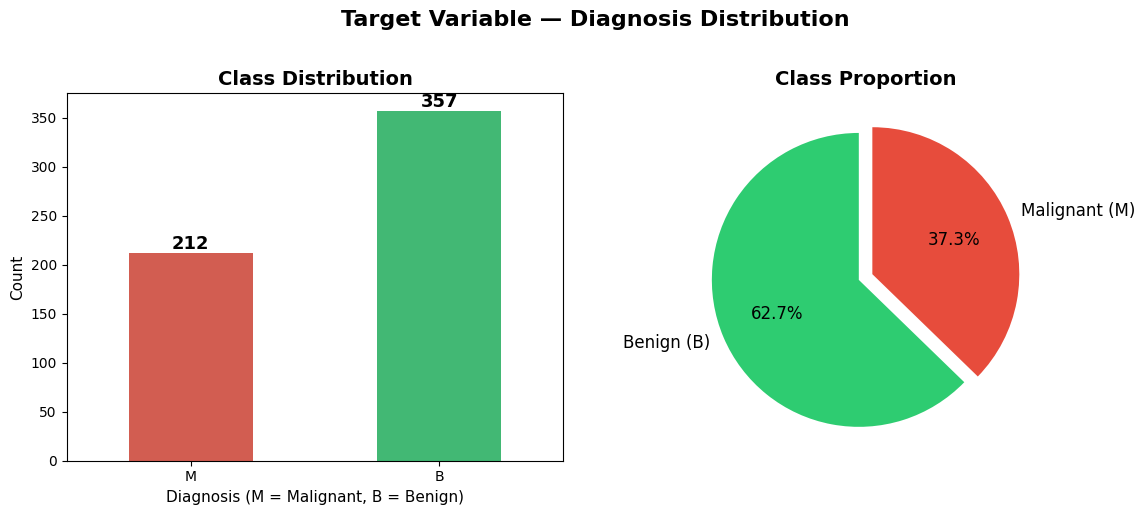


Benign (B):    357 samples (62.7%)
Malignant (M): 212 samples (37.3%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='diagnosis', data=df,
              palette={'M': '#e74c3c', 'B': '#2ecc71'},
              ax=axes[0], width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis (M = Malignant, B = Benign)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

counts = df['diagnosis'].value_counts()
axes[1].pie(counts,
            labels=['Benign (B)', 'Malignant (M)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0.05, 0.05),
            textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Diagnosis Distribution',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBenign (B):    {counts['B']} samples ({counts['B']/len(df)*100:.1f}%)")
print(f"Malignant (M): {counts['M']} samples ({counts['M']/len(df)*100:.1f}%)")

Let's view feature distribution.

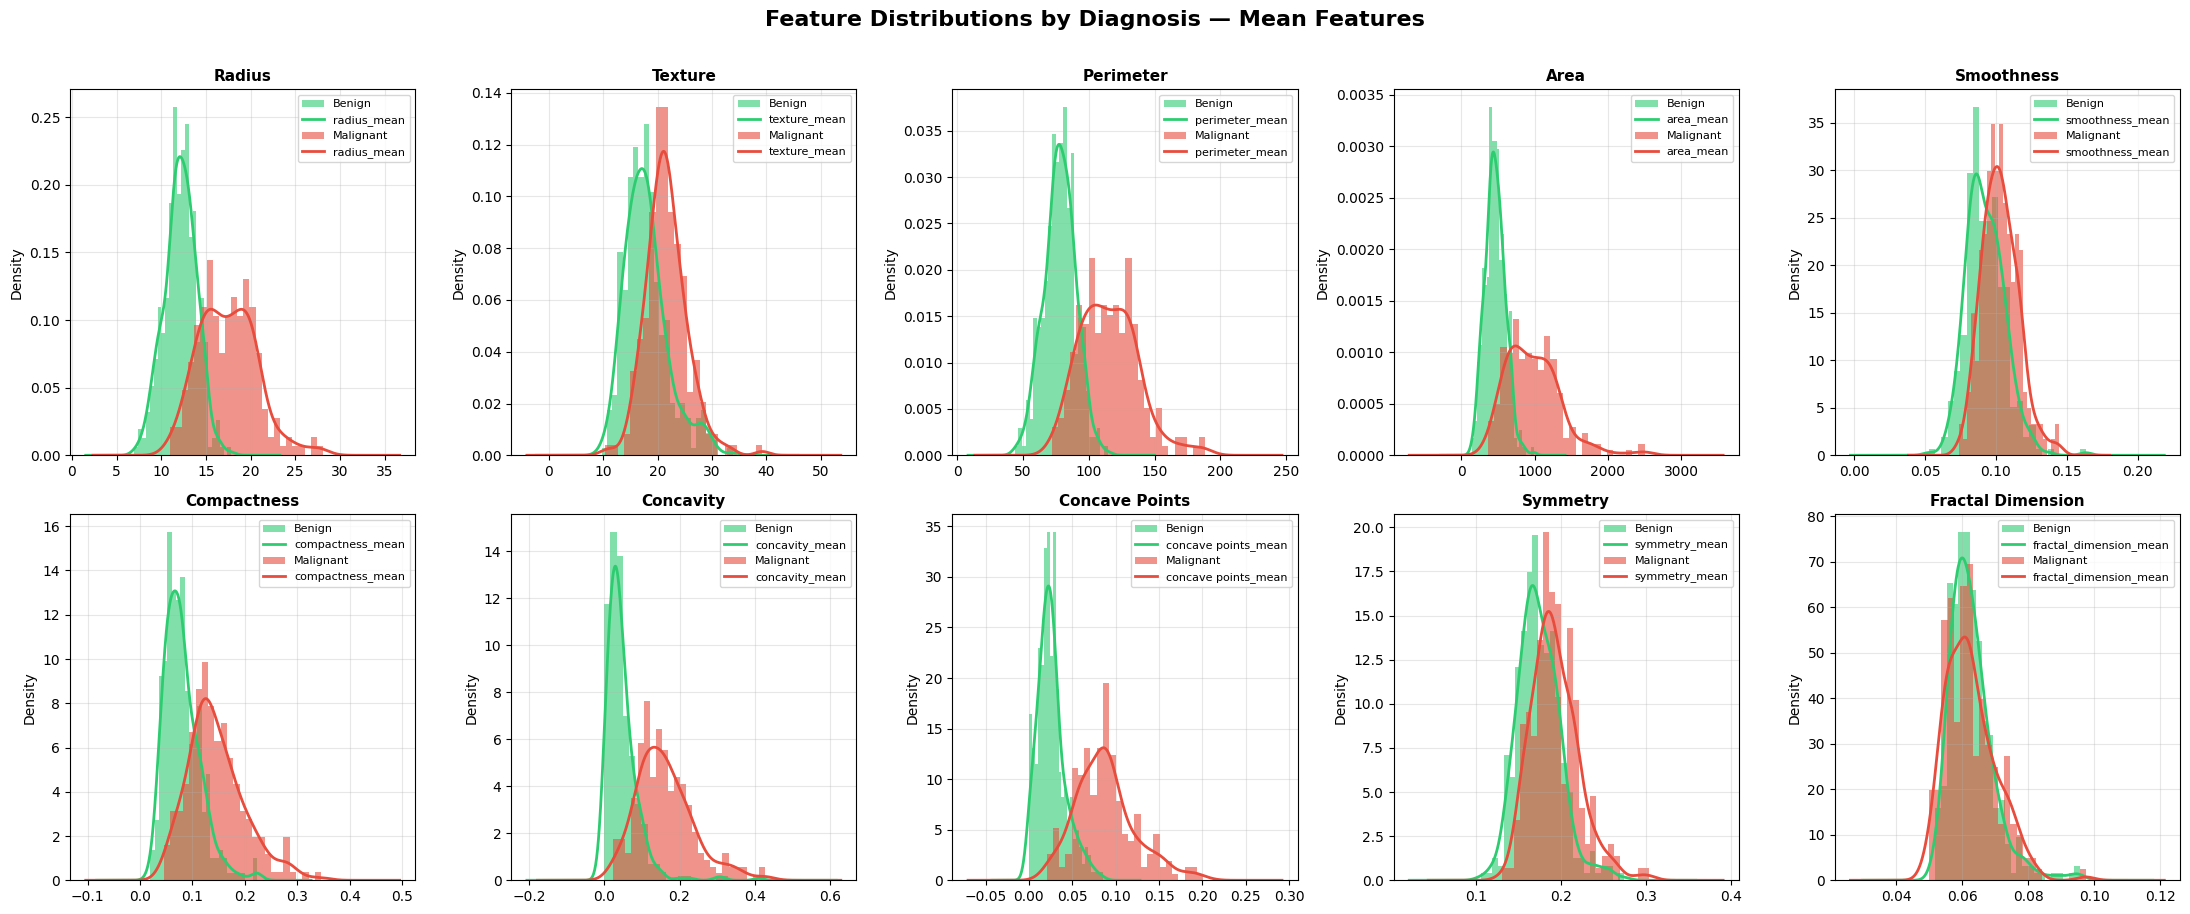

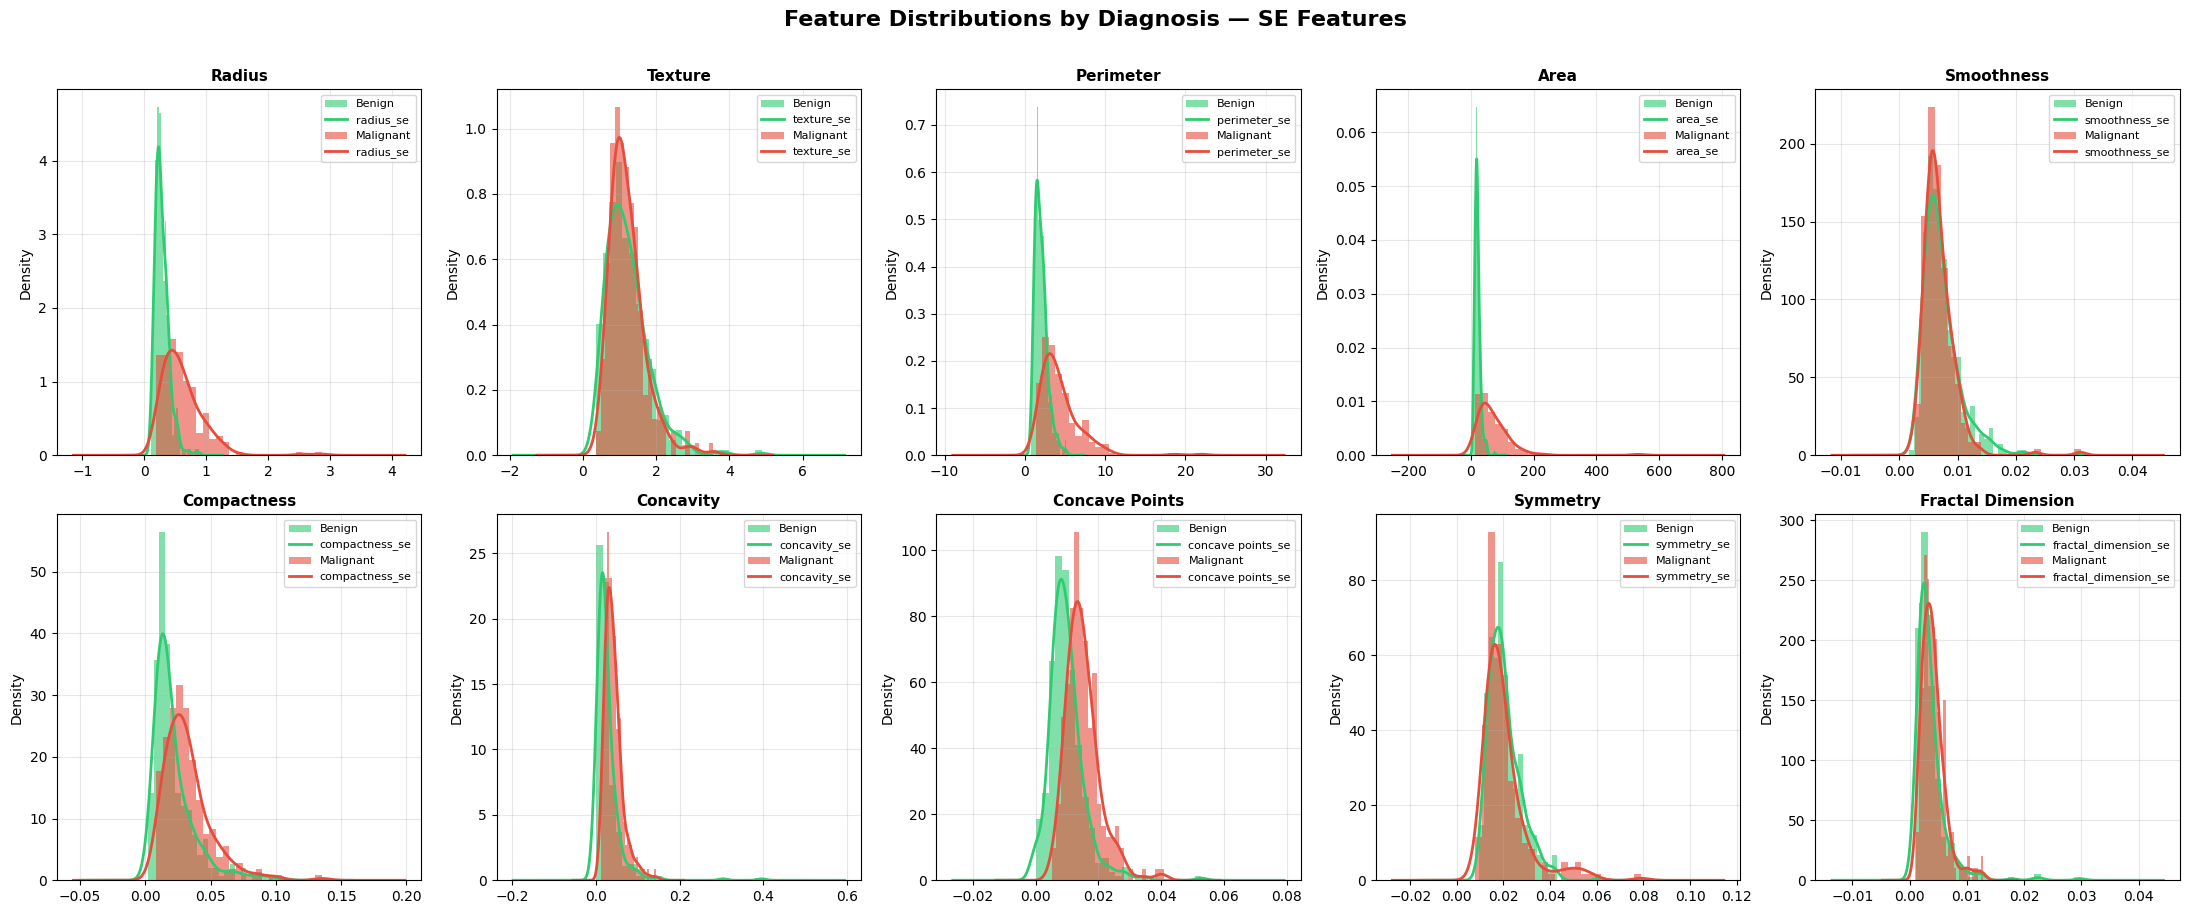

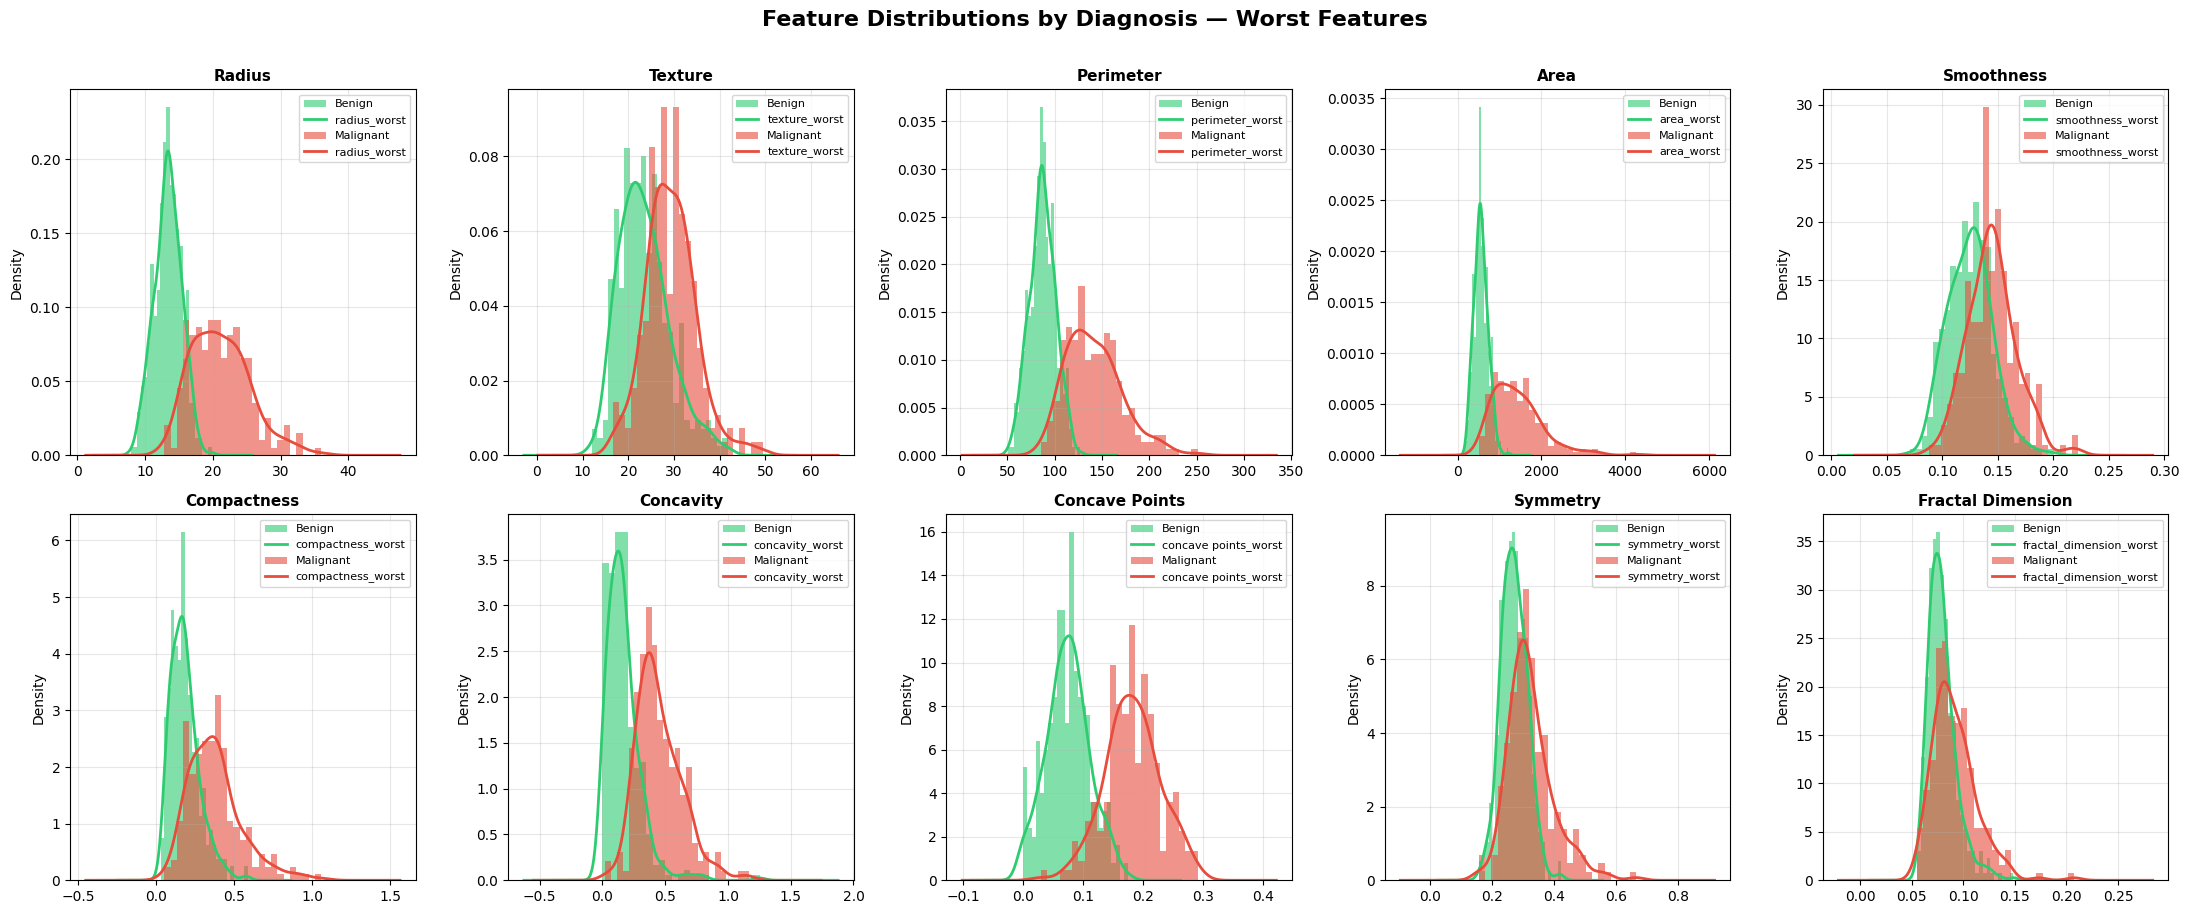

Feature distribution plots done


In [ ]:
mean_features = [col for col in df.columns if '_mean' in col]
se_features   = [col for col in df.columns if '_se' in col]
worst_features = [col for col in df.columns if '_worst' in col]

def plot_feature_distributions(features, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes = axes.flatten()
    for i, feature in enumerate(features):
        for diagnosis, color, label in [('B', '#2ecc71', 'Benign'),
                                         ('M', '#e74c3c', 'Malignant')]:
            subset = df[df['diagnosis'] == diagnosis][feature]
            axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                         label=label, density=True)
            subset.plot.kde(ax=axes[i], color=color, linewidth=2)

        axes[i].set_title(feature.replace('_mean','').replace('_se','')
                          .replace('_worst','').replace('_',' ').title(),
                          fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_feature_distributions(mean_features,
    'Feature Distributions by Diagnosis — Mean Features',
    'eda_02_dist_mean.png')

plot_feature_distributions(se_features,
    'Feature Distributions by Diagnosis — SE Features',
    'eda_03_dist_se.png')

plot_feature_distributions(worst_features,
    'Feature Distributions by Diagnosis — Worst Features',
    'eda_04_dist_worst.png')

print("Feature distribution plots done")

Let's view boxplots by class.

In [ ]:
def plot_boxplots(features, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    axes = axes.flatten()

    for i, feature in enumerate(features):
        sns.boxplot(data=df, x='diagnosis', y=feature,
                    palette={'B': '#2ecc71', 'M': '#e74c3c'},
                    ax=axes[i], width=0.5, linewidth=1.5,
                    flierprops=dict(marker='o', markerfacecolor='gray',
                                   markersize=4, alpha=0.5))

        sns.stripplot(data=df, x='diagnosis', y=feature,
                      color='black', alpha=0.15, size=2.5, ax=axes[i])

        axes[i].set_title(feature.replace('_mean','').replace('_se','')
                          .replace('_worst','').replace('_',' ').title(),
                          fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].grid(True, alpha=0.3, axis='y')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_boxplots(mean_features,
    'Boxplots by Diagnosis — Mean Features',
    'eda_05_box_mean.png')

plot_boxplots(se_features,
    'Boxplots by Diagnosis — SE Features',
    'eda_06_box_se.png')

plot_boxplots(worst_features,
    'Boxplots by Diagnosis — Worst Features',
    'eda_07_box_worst.png')


Let's create the correlation heatmap.

In [ ]:

df_corr = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore').copy()
df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

corr = df_corr.corr()

plt.figure(figsize=(26, 22))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.4,
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'})

plt.title('Full Feature Correlation Matrix (incl. Diagnosis)',
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('eda_08_full_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("FEATURES MOST CORRELATED WITH DIAGNOSIS")
print("(M=1, B=0 — higher = more linked to malignant)")
print("=" * 50)
diag_corr = corr['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print(diag_corr.round(3).to_string())


Let's create feature outcome bar charts.

In [ ]:

df_plot = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore').copy()

benign    = df_plot[df_plot['diagnosis'] == 'B'].drop(columns='diagnosis')
malignant = df_plot[df_plot['diagnosis'] == 'M'].drop(columns='diagnosis')

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
all_vals = pd.DataFrame(scaler.fit_transform(df_plot.drop(columns='diagnosis')),
                        columns=df_plot.drop(columns='diagnosis').columns)
all_vals['diagnosis'] = df_plot['diagnosis'].values

b_means = all_vals[all_vals['diagnosis'] == 'B'].drop(columns='diagnosis').mean()
m_means = all_vals[all_vals['diagnosis'] == 'M'].drop(columns='diagnosis').mean()

x = np.arange(len(b_means))
width = 0.4

fig, axes = plt.subplots(3, 1, figsize=(22, 18))

feature_groups = [
    (mean_features,  'Mean Features'),
    (se_features,    'SE Features'),
    (worst_features, 'Worst Features')
]

for ax, (features, title) in zip(axes, feature_groups):
    idx = [list(b_means.index).index(f) for f in features]
    x_g = np.arange(len(features))

    bars_b = ax.bar(x_g - width/2, b_means.iloc[idx], width,
                    label='Benign',    color='#2ecc71', alpha=0.85, edgecolor='white')
    bars_m = ax.bar(x_g + width/2, m_means.iloc[idx], width,
                    label='Malignant', color='#e74c3c', alpha=0.85, edgecolor='white')

    ax.set_xticks(x_g)
    ax.set_xticklabels([f.replace('_mean','').replace('_se','')
                         .replace('_worst','').replace('_',' ').title()
                         for f in features], rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Normalized Mean Value', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)

plt.suptitle('Normalized Mean Feature Values — Benign vs Malignant',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_12_feature_outcome_barchart.png', dpi=150, bbox_inches='tight')
plt.show()


# Let's go to data preprocessing.

In [ ]:
print("=" * 55)
print("BEFORE PREPROCESSING")
print("=" * 55)
print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Now, we will drop columns that are irrelavant to our outcome.

In [ ]:
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore').copy()
print(f"\nDropped 'id' and 'Unnamed: 32' — New shape: {df_clean.shape}")

Now, we will encode target variables.

In [ ]:
le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis'])
# M=1 (Malignant), B=0 (Benign)
print(f"\nEncoded diagnosis — M=1, B=0")
print(f"Class counts:\n{pd.Series(df_clean['diagnosis']).value_counts()}")

Let'c check and handle missing values.

In [ ]:
missing = df_clean.isnull().sum()
if missing.sum() == 0:
    print(f"\nNo missing values found — no imputation needed")
else:
    df_clean.fillna(df_clean.median(), inplace=True)
    print(f"\nFilled {missing.sum()} missing values with column median")

Let's define features and target.

In [ ]:
X = df_clean.drop(columns='diagnosis')
y = df_clean['diagnosis']
print(f"\nFeatures (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"Feature names: {X.columns.tolist()}")

Let's split the data between train, test and validation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain/Test Split (80/20, stratified):")
print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   y_train distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"   y_test  distribution: {pd.Series(y_test).value_counts().to_dict()}")

# Implementation.

Now, we will implement CART with Gini criterion.

We will first train the Tree without any tuning.

In [ ]:
cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_base.fit(X_train, y_train)
base_score = cross_val_score(cart_base, X_train, y_train, cv=5, scoring='accuracy').mean()
print(f"\nBaseline CART (no tuning) CV Accuracy: {base_score:.4f}")

Hyper parameter grid.

In [ ]:
param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf' : [1, 2, 4, 6]
}

Let's train a model for every parameter combination using 5-fold cross-validation and picks the one with the highest mean CV accuracy using GridSearchCV.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_cart = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_cart.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_cart.best_params_}")
print(f"Best CV Accuracy: {grid_cart.best_score_:.4f}")

Let's evaluate our optimized model.

In [ ]:
cart_best = grid_cart.best_estimator_
y_pred_cart = cart_best.predict(X_test)
y_prob_cart = cart_best.predict_proba(X_test)[:, 1]

print(f"\nOptimized CART Test Accuracy: {accuracy_score(y_test, y_pred_cart):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_cart, target_names=['Benign','Malignant'])}")

Let's draw CV scroe plot.

In [ ]:
cv_scores_cart = cross_val_score(cart_best, X_train, y_train, cv=cv, scoring='accuracy')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores_cart, marker='o', color='#3498db',
         linewidth=2, markersize=8, label='Fold Accuracy')
plt.axhline(cv_scores_cart.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean: {cv_scores_cart.mean():.4f}')
plt.fill_between(range(1, 6),
                 cv_scores_cart.mean() - cv_scores_cart.std(),
                 cv_scores_cart.mean() + cv_scores_cart.std(),
                 alpha=0.2, color='#3498db', label=f'±1 Std: {cv_scores_cart.std():.4f}')
plt.title('CART — Cross Validation Accuracy per Fold', fontsize=14, fontweight='bold')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(1, 6))
plt.ylim(0.85, 1.01)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cart_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

Let's draw max_depth vs accuracy plot.

In [ ]:
depths = [3, 4, 5, 6, 7, 8, 10, 15, 20]
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  clf.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy',
         color='#2ecc71', linewidth=2)
plt.plot(depths, test_scores,  marker='s', label='Test Accuracy',
         color='#e74c3c', linewidth=2)
plt.axvline(grid_cart.best_params_['max_depth'], color='gray',
            linestyle='--', label=f"Best depth = {grid_cart.best_params_['max_depth']}")
plt.title('CART — max_depth vs Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cart_depth_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

Let's implement ID3 and hyper parameter tuning.

ID3 without any tuning.

In [ ]:
id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_base.fit(X_train, y_train)
base_score_id3 = cross_val_score(id3_base, X_train, y_train, cv=5, scoring='accuracy').mean()
print(f"\nBaseline ID3 (no tuning) CV Accuracy: {base_score_id3:.4f}")

Hyper parameter grid.

In [ ]:
param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf' : [1, 2, 4, 6]
}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_id3 = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_id3.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_id3.best_params_}")
print(f"Best CV Accuracy: {grid_id3.best_score_:.4f}")

Let's train optimized ID3.

In [ ]:
id3_best = grid_id3.best_estimator_
y_pred_id3 = id3_best.predict(X_test)
y_prob_id3 = id3_best.predict_proba(X_test)[:, 1]

print(f"\nOptimized ID3 Test Accuracy: {accuracy_score(y_test, y_pred_id3):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_id3, target_names=['Benign','Malignant'])}")

Let's draw CV score distribution plot.

In [ ]:
cv_scores_id3 = cross_val_score(id3_best, X_train, y_train, cv=cv, scoring='accuracy')

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_scores_id3, marker='o', color='#e67e22',
         linewidth=2, markersize=8, label='Fold Accuracy')
plt.axhline(cv_scores_id3.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean: {cv_scores_id3.mean():.4f}')
plt.fill_between(range(1, 6),
                 cv_scores_id3.mean() - cv_scores_id3.std(),
                 cv_scores_id3.mean() + cv_scores_id3.std(),
                 alpha=0.2, color='#e67e22', label=f'±1 Std: {cv_scores_id3.std():.4f}')
plt.title('ID3 — Cross Validation Accuracy per Fold', fontsize=14, fontweight='bold')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(1, 6))
plt.ylim(0.85, 1.01)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('id3_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

Let's draw max depth vs accuracy plot.

In [ ]:
depths = [3, 4, 5, 6, 7, 8, 10, 15, 20]
train_scores_id3, test_scores_id3 = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores_id3.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores_id3.append(accuracy_score(y_test,  clf.predict(X_test)))

plt.figure(figsize=(9, 4))
plt.plot(depths, train_scores_id3, marker='o', label='Train Accuracy',
         color='#2ecc71', linewidth=2)
plt.plot(depths, test_scores_id3,  marker='s', label='Test Accuracy',
         color='#e74c3c', linewidth=2)
plt.axvline(grid_id3.best_params_['max_depth'], color='gray',
            linestyle='--', label=f"Best depth = {grid_id3.best_params_['max_depth']}")
plt.title('ID3 — max_depth vs Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('id3_depth_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


# Now, we will perform all required visualizations.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

We will show decision boundary plot.
Our dataset has too many features, so we cant plot all of them directly. We will use PCA to reduce to 2 components just for visualization.

The models are retrained on these 2 components ONLY for plotting.
The actual model performance uses all 30 features.

first (PCA needs scaling), then reduce to 2D

In [ ]:
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled  = scaler_pca.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

In [ ]:
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")


Retrain both models on 2D PCA data just for boundary visualization

In [ ]:
cart_pca = DecisionTreeClassifier(criterion='gini',
                                   **{k:v for k,v in grid_cart.best_params_.items()},
                                   random_state=42)
cart_pca.fit(X_train_pca, y_train)

id3_pca = DecisionTreeClassifier(criterion='entropy',
                                  **{k:v for k,v in grid_id3.best_params_.items()},
                                  random_state=42)
id3_pca.fit(X_train_pca, y_train)


Build a mesh grid across the 2D PCA space.
Every point in the grid gets a predicted class — this forms the colored background

In [ ]:
x_min = X_test_pca[:, 0].min() - 1
x_max = X_test_pca[:, 0].max() + 1
y_min = X_test_pca[:, 1].min() - 1
y_max = X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title, color in zip(
        axes,
        [cart_pca, id3_pca],
        ['CART (Gini)', 'ID3 (Entropy)'],
        ['Blues', 'Oranges']):

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap=color)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8, alpha=0.5)

    for cls, marker, label, c in [(0, 'o', 'Benign',    '#2ecc71'),
                                   (1, '^', 'Malignant', '#e74c3c')]:
        mask = y_test == cls
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                   c=c, marker=marker, edgecolors='black',
                   linewidths=0.5, s=55, label=label, alpha=0.85)

    ax.set_title(f'Decision Boundary — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA Component 1', fontsize=11)
    ax.set_ylabel('PCA Component 2', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

plt.suptitle('Decision Boundary Comparison (PCA 2D Projection)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_01_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

Let's draw confusion matrix.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in zip(
        axes,
        [y_pred_cart, y_pred_id3],
        ['CART (Gini)', 'ID3 (Entropy)'],
        ['Blues', 'Oranges']):

    cm = confusion_matrix(y_test, y_pred)

    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

    labels = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                        for row_v, row_p in zip(cm, cm_pct)])

    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap,
                ax=ax, linewidths=1, linecolor='white',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                cbar_kws={'shrink': 0.8})

    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Let's draw ROC curve.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_prob, title, color in zip(
        axes,
        [y_prob_cart, y_prob_id3],
        ['CART (Gini)', 'ID3 (Entropy)'],
        ['#3498db', '#e67e22']):

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Random Guess')
    ax.fill_between(fpr, tpr, alpha=0.15, color=color)

    ax.set_title(f'ROC Curve — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle('ROC Curve Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_03_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Let's form evaluation metrics and Bar Chart.


EVALUATION METRICS SUMMARY
           CART (Gini)  ID3 (Entropy)
Accuracy        0.9211         0.9298
Precision       0.9231         1.0000
Recall          0.8571         0.8095
F1 Score        0.8889         0.8947
AUC             0.9173         0.9563


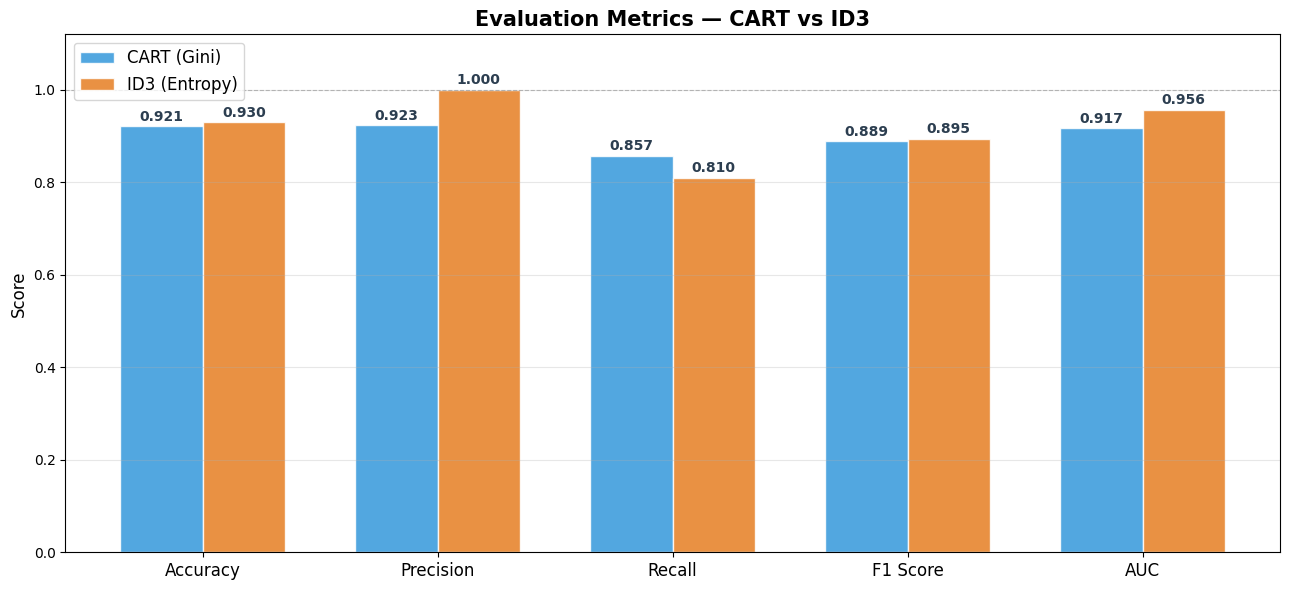

In [ ]:
metrics = {
    'Accuracy' : [accuracy_score(y_test, y_pred_cart),
                  accuracy_score(y_test, y_pred_id3)],
    'Precision': [precision_score(y_test, y_pred_cart),
                  precision_score(y_test, y_pred_id3)],
    'Recall'   : [recall_score(y_test, y_pred_cart),
                  recall_score(y_test, y_pred_id3)],
    'F1 Score' : [f1_score(y_test, y_pred_cart),
                  f1_score(y_test, y_pred_id3)],
    'AUC'      : [auc(*roc_curve(y_test, y_prob_cart)[:2]),
                  auc(*roc_curve(y_test, y_prob_id3)[:2])]
}

metrics_df = pd.DataFrame(metrics, index=['CART (Gini)', 'ID3 (Entropy)']).T
print("\n" + "=" * 45)
print("EVALUATION METRICS SUMMARY")
print("=" * 45)
print(metrics_df.round(4).to_string())

x      = np.arange(len(metrics))
width  = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, metrics_df['CART (Gini)'],   width,
               label='CART (Gini)',   color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, metrics_df['ID3 (Entropy)'], width,
               label='ID3 (Entropy)', color='#e67e22', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='#2c3e50')

for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Evaluation Metrics — CART vs ID3', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('viz_04_metrics_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

Let's visualize decision tree structure.

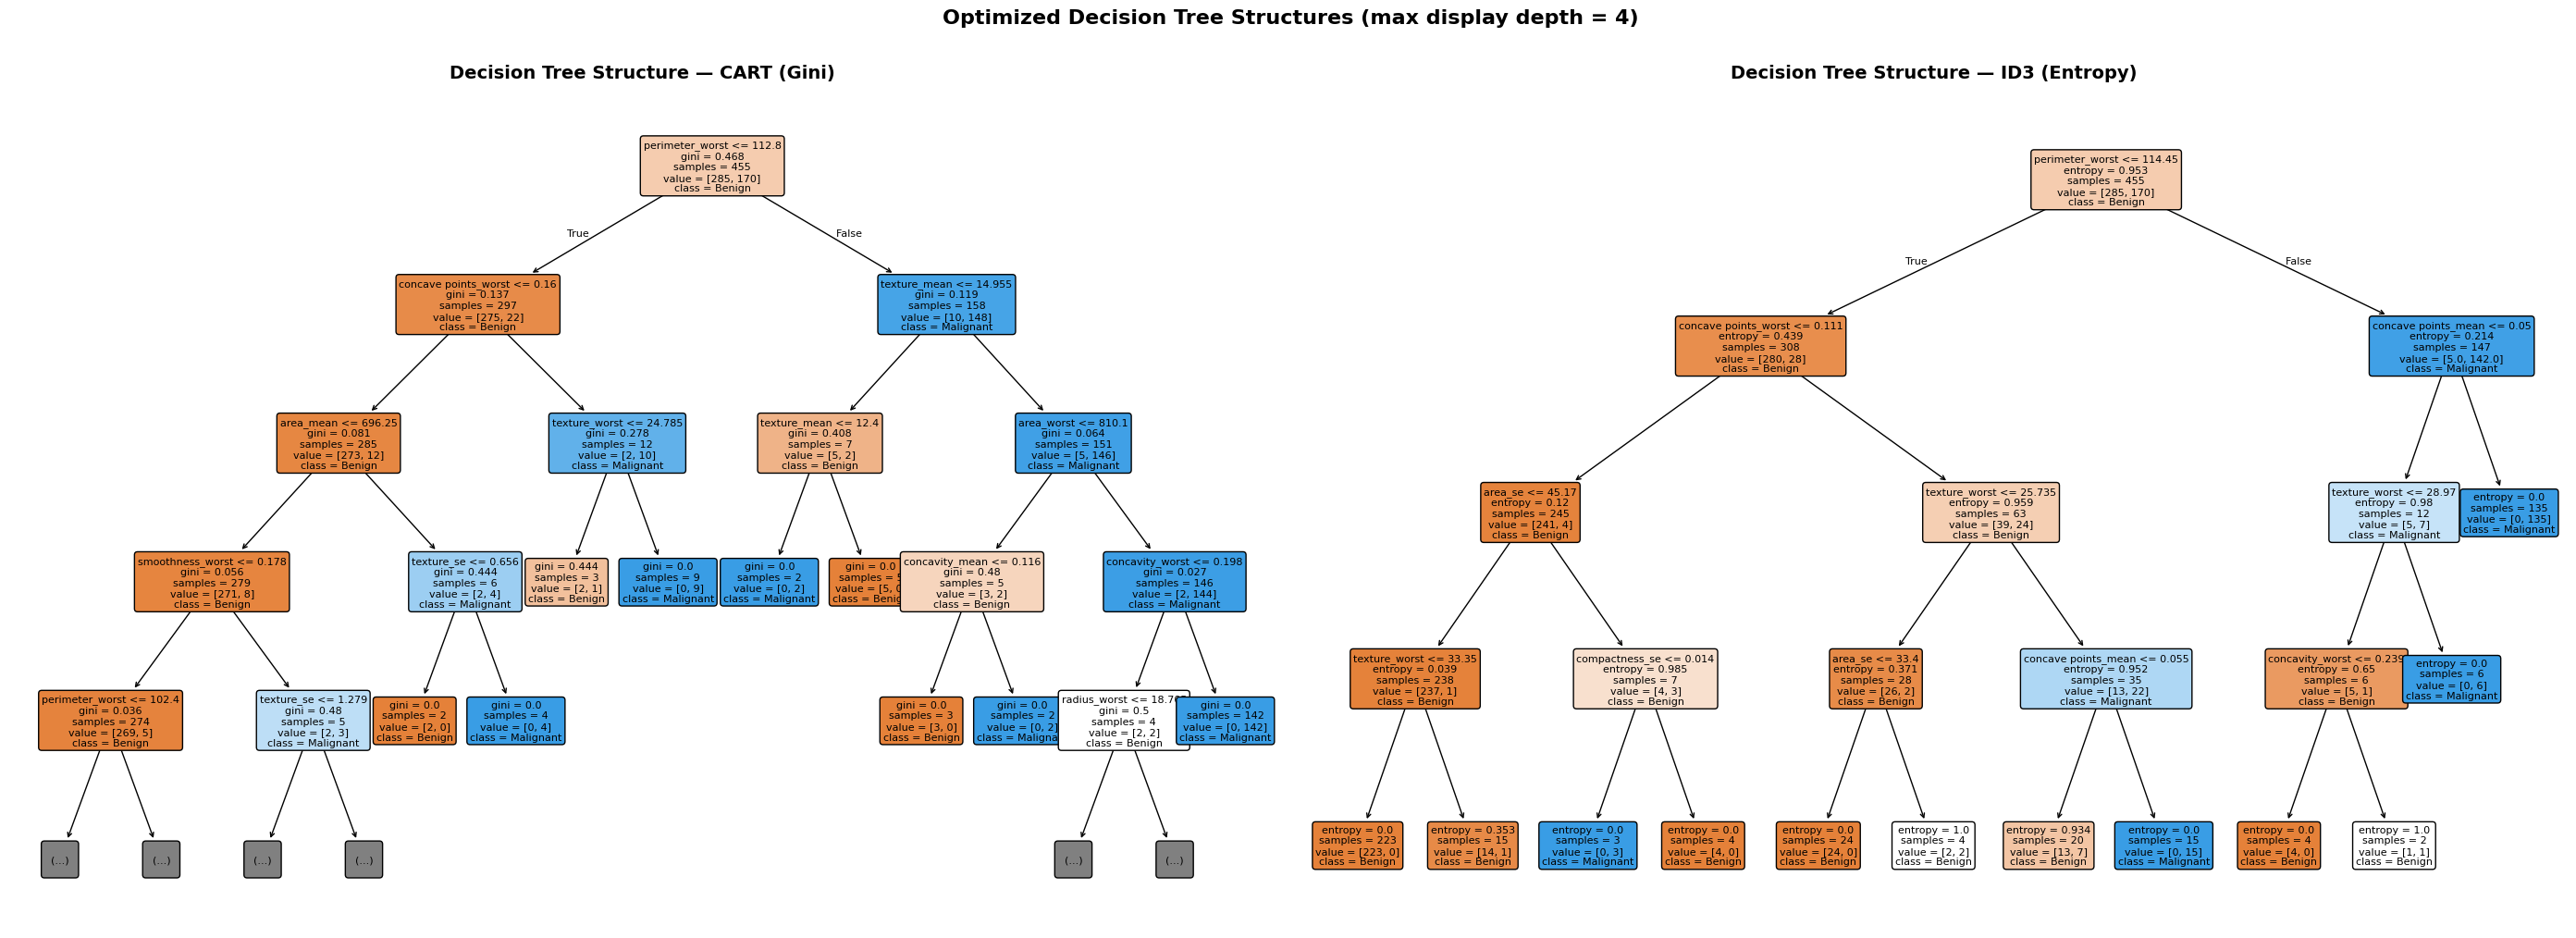


CART — Text Tree Structure (max depth 3)
|--- perimeter_worst <= 112.80
|   |--- concave points_worst <= 0.16
|   |   |--- area_mean <= 696.25
|   |   |   |--- smoothness_worst <= 0.18
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- smoothness_worst >  0.18
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- area_mean >  696.25
|   |   |   |--- texture_se <= 0.66
|   |   |   |   |--- class: 0
|   |   |   |--- texture_se >  0.66
|   |   |   |   |--- class: 1
|   |--- concave points_worst >  0.16
|   |   |--- texture_worst <= 24.78
|   |   |   |--- class: 0
|   |   |--- texture_worst >  24.78
|   |   |   |--- class: 1
|--- perimeter_worst >  112.80
|   |--- texture_mean <= 14.95
|   |   |--- texture_mean <= 12.40
|   |   |   |--- class: 1
|   |   |--- texture_mean >  12.40
|   |   |   |--- class: 0
|   |--- texture_mean >  14.95
|   |   |--- area_worst <= 810.10
|   |   |   |--- concavity_mean <= 0.12
|   |   |   |   |--- class: 0
|   |   |   |--- concavity_m

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(28, 10))

for ax, model, title, color in zip(
        axes,
        [cart_best, id3_best],
        ['CART (Gini)', 'ID3 (Entropy)'],
        ['#3498db', '#e67e22']):

    plot_tree(model,
              feature_names=X.columns.tolist(),
              class_names=['Benign', 'Malignant'],
              filled=True,
              rounded=True,
              max_depth=4,
              fontsize=8,
              ax=ax,
              impurity=True,
              proportion=False)

    ax.set_title(f'Decision Tree Structure — {title}',
                 fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Optimized Decision Tree Structures (max display depth = 4)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_05_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 55)
print("CART — Text Tree Structure (max depth 3)")
print("=" * 55)
print(export_text(cart_best, feature_names=X.columns.tolist(), max_depth=3))

print("\n" + "=" * 55)
print("ID3 — Text Tree Structure (max depth 3)")
print("=" * 55)
print(export_text(id3_best, feature_names=X.columns.tolist(), max_depth=3))